In [67]:
import numpy as np
import matplotlib.pyplot as plt
import os

# reproducible random number generator
RNG = np.random.default_rng(42)

In [68]:
def read_dataset(
    data_dir="MNIST-5-6-Subset",
    corruption=0,
    dimensions=784,
):
    corruption_levels = [None, "Light", "Moderate", "Heavy"]
    corruption = corruption_levels[corruption]

    file_prefix = os.path.join(data_dir, "MNIST-5-6-Subset")
    data_file_path = (
        file_prefix
        + ("" if corruption is None else f"-{corruption}-Corruption")
        + ".txt"
    )
    # transpose to get every data point as a column vector
    data_matrix = np.loadtxt(data_file_path).reshape(-1, dimensions).T

    labels_file_path = file_prefix + "-Labels.txt"
    labels = np.loadtxt(labels_file_path)

    return data_matrix, labels

In [69]:
def show_image(index, data_matrix, labels, figshape=(28, 28)):
    data = data_matrix[:, index]
    label = int(labels[index])

    plt.imshow(data.reshape(figshape).T, cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")  # Turn off axis
    plt.show()

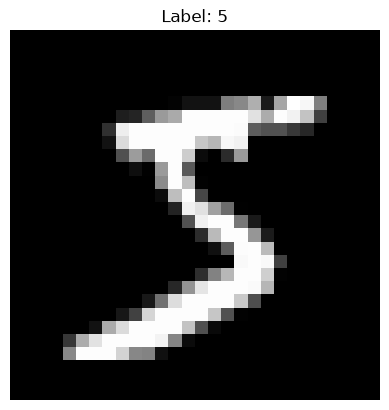

In [70]:
data_matrix, labels = read_dataset()

image_index = 0
show_image(image_index, data_matrix, labels)

In [71]:
def knn(training_points, training_labels, test_points, test_labels, rng=RNG):
    # rename to match the assignment notations
    X_train = training_points
    X_targ = test_points
    d, m = X_train.shape
    _, n = X_targ.shape

    assert X_targ.shape == (d, n)
    assert training_labels.shape == (m,)
    assert test_labels.shape == (n,)

    # compute the distances matrix
    XTX_train_diag = np.diag(X_train.T @ X_train).reshape(-1, 1)
    XTX_targ_diag = np.diag(X_targ.T @ X_targ).reshape(-1, 1)
    ones_n = np.ones((n, 1))
    ones_m = np.ones((m, 1))
    D = (
        (XTX_train_diag @ ones_n.T)
        - (2 * X_train.T @ X_targ)
        + (ones_m @ XTX_targ_diag.T)
    )
    assert D.shape == (m, n)

    # by mapping the labels {5, 6} to {-1, 1},
    # we can use the sum of the labels to determine the majority vote
    def labels_to_y(labels):
        return np.where(labels == 5, -1, 1)

    Y_train = labels_to_y(training_labels)
    Y_targ = labels_to_y(test_labels)

    distances_sorted_idx = np.argsort(D, axis=0)
    Y_train_sorted = Y_train[distances_sorted_idx]
    Y_train_running_sum = np.cumsum(Y_train_sorted, axis=0)

    # since the labels are {-1, 1}, the sign of the running sum gives the majority vote,
    # and we can break ties by randomly choosing a label
    tie_break = rng.choice([-1, 1], size=Y_train_running_sum.shape)
    prediction = np.where(
        Y_train_running_sum == 0, tie_break, np.sign(Y_train_running_sum)
    )

    # compare to the true labels and compute the accuracy for each K
    correct = prediction != Y_targ.T
    error_per_K = np.mean(correct, axis=1)
    return error_per_K

In [72]:
m = 50

def get_validation_set(i, n, offset=m, data=data_matrix, labels=labels):
    # i is 0-indexed instead of 1-indexed like in the assignment description
    start = offset + (i * n)
    end = offset + ((i + 1) * n)
    return data[:, start:end], labels[start:end]

training_points, training_labels = get_validation_set(0, m, offset=0)

In [73]:
ns = [10, 20, 40, 80]
n_validation_sets = 5
Ks = np.arange(1, m + 1)

errors = np.empty((len(ns), n_validation_sets, len(Ks)))
for n in ns:
    for i in range(n_validation_sets):
        validation_points, validation_labels = get_validation_set(i, n)
        errors[ns.index(n), i, :] = knn(
            training_points, training_labels, validation_points, validation_labels
        )

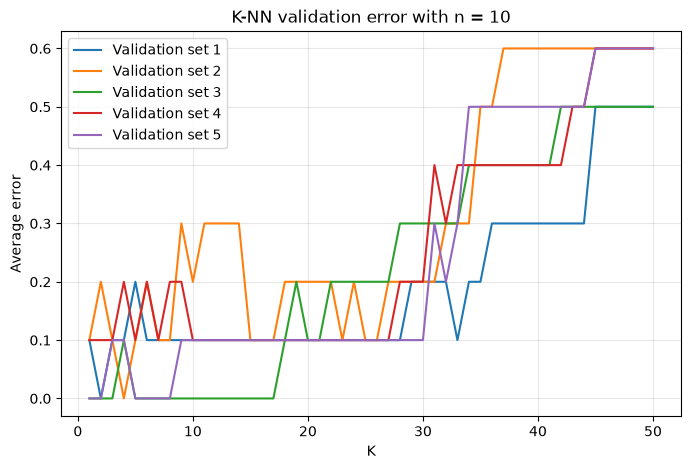

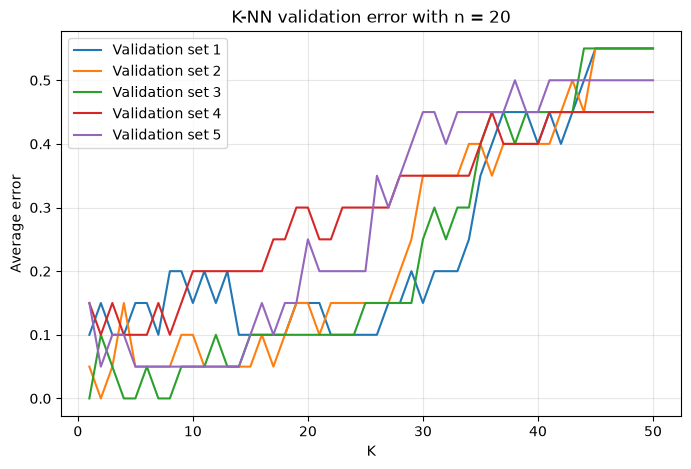

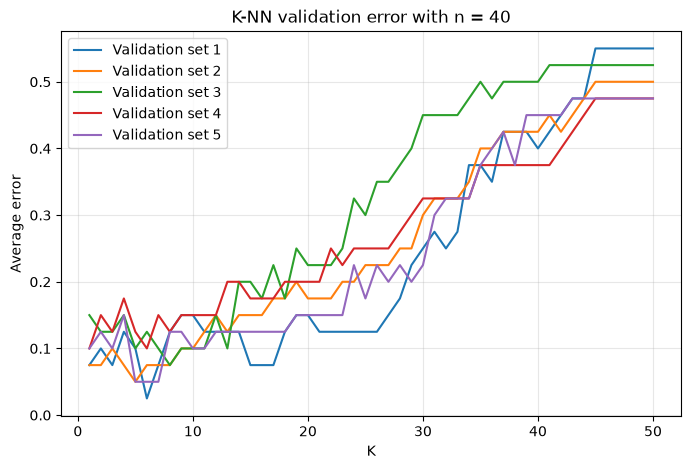

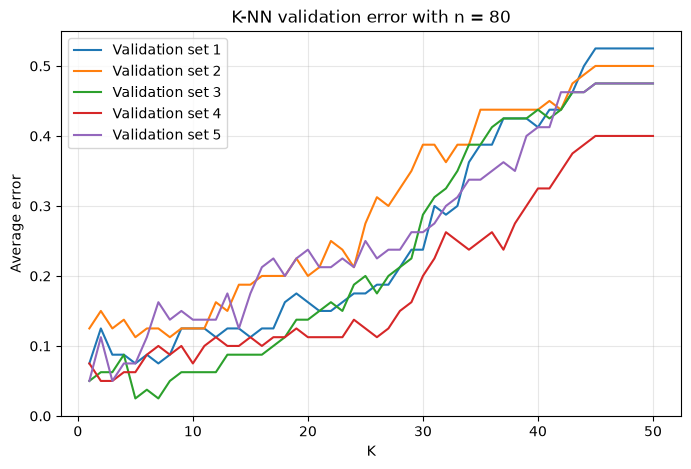

In [74]:
figs_dir = "plots"
if not os.path.exists(figs_dir):
    os.makedirs(figs_dir)

for n_idx, n in enumerate(ns):
    fig, ax = plt.subplots(figsize=(8, 5))
    for i in range(5):
        ax.plot(Ks, errors[n_idx][i], label=f"Validation set {i+1}")
    ax.set_xlabel("K")
    ax.set_ylabel("Average error")
    ax.set_title(f"K-NN validation error with n = {n}")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.show()

    fig_file_path = os.path.join(figs_dir, f"knn_validation_error_n_{n}.png")
    fig.savefig(fig_file_path, dpi=300)

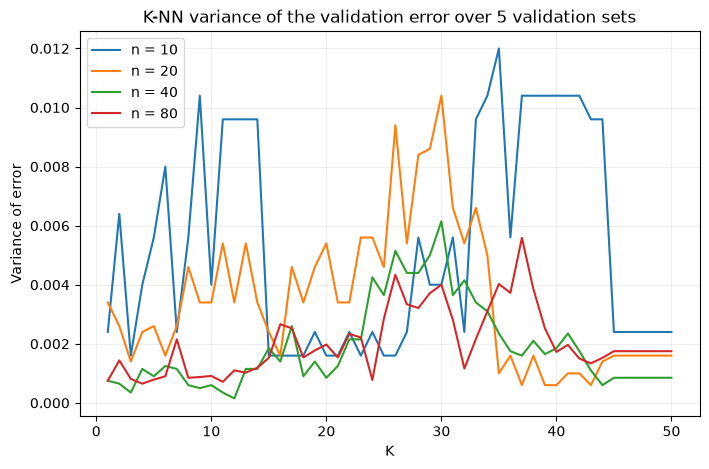

In [75]:
fig, ax = plt.subplots(figsize=(8, 5))
for n_idx, n in enumerate(ns):
    variance_curve = errors[n_idx].var(axis=0)
    ax.plot(Ks, variance_curve, label=f"n = {n}")
ax.set_xlabel("K")
ax.set_ylabel("Variance of error")
ax.set_title(f"K-NN variance of the validation error over {n_validation_sets} validation sets")
ax.grid(alpha=0.2)
ax.legend()
plt.show()

fig_file_path = os.path.join(figs_dir, f"knn_validation_error_variance.png")
fig.savefig(fig_file_path, dpi=300)